In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [2]:
onejet_sample = pd.read_pickle('../../DMSimp_S3D_uR_1j-full_CMS_BPs/Events/run_01/scanResults_S3D_uR_1j-full_CMS_BPs.pcl')
twojets_sample = pd.read_pickle('../../DMSimp_S3D_uR_2j-full_CMS_BPs/Events/run_01/scanResults_S3D_uR_2j-full_CMS_BPs.pcl')

In [3]:
onejet_sample

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Electronveto,Muonveto,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$)
0,tchannel,DM+QCDjets,100.0,1.0,2018,59.7,50483.384108,2635.211200,2635.211200,33151.214087,...,0.219139,0.219023,0.211769,0.185053,0.176532,0.175610,0.173307,0.173307,0.167319,0.145094
1,tchannel,DM+QCDjets,100.0,1.0,2017,41.5,45944.006246,2513.944172,2513.944172,27511.380985,...,0.222973,0.222808,0.216216,0.190013,0.181773,0.181444,0.179136,0.179136,0.179136,0.179136
2,tchannel,DM+QCDjets,100.0,1.0,2016,36.0,39341.274809,2326.298347,2326.298347,28474.279320,...,0.233871,0.233871,0.229071,0.201613,0.191436,0.190476,0.187980,0.187980,0.187980,0.187980
3,tchannel,DM+QCDjets,100.0,75.0,2018,59.7,6896.800283,301.001041,301.001041,4781.781530,...,0.292592,0.292592,0.284616,0.250889,0.243682,0.242913,0.239839,0.239839,0.230902,0.198424
4,tchannel,DM+QCDjets,100.0,75.0,2017,41.5,5451.756415,267.616197,267.616197,4085.533120,...,0.289441,0.289303,0.282402,0.250518,0.242650,0.242236,0.238923,0.238923,0.238923,0.238923
5,tchannel,DM+QCDjets,100.0,75.0,2016,36.0,5451.756415,267.616197,267.616197,3244.780324,...,0.296419,0.296261,0.289005,0.247673,0.239785,0.239470,0.236630,0.236630,0.236630,0.236630
6,tchannel,DM+QCDjets,300.0,1.0,2018,59.7,17250.702392,794.870408,794.870408,11610.345347,...,0.199461,0.199201,0.193554,0.176353,0.165494,0.164538,0.163061,0.163061,0.157067,0.135957
7,tchannel,DM+QCDjets,300.0,1.0,2017,41.5,14503.775260,728.842130,728.842130,8240.781398,...,0.206061,0.206061,0.201838,0.181592,0.169668,0.168923,0.168054,0.168054,0.168054,0.168054
8,tchannel,DM+QCDjets,300.0,1.0,2016,36.0,12525.987724,677.327843,677.327843,7947.775837,...,0.199801,0.199801,0.194831,0.177080,0.165578,0.164584,0.163306,0.163306,0.163306,0.163306
9,tchannel,DM+QCDjets,300.0,200.0,2018,59.7,4214.793912,174.409413,174.409413,2807.456904,...,0.295362,0.295182,0.284106,0.247366,0.240973,0.240522,0.236650,0.236650,0.226925,0.195768


In [4]:
twojets_sample

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Electronveto,Muonveto,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$)
0,tchannel,DM+QCDjets,100.0,1.0,2018,59.7,31011.509649,8288.174582,8288.174582,19935.970489,...,0.109735,0.109735,0.104425,0.084956,0.081416,0.081416,0.081416,0.081416,0.076106,0.063717
1,tchannel,DM+QCDjets,100.0,1.0,2017,41.5,39871.940978,9397.906615,9397.906615,15505.754825,...,0.122195,0.122195,0.114713,0.097257,0.094763,0.094763,0.089776,0.089776,0.089776,0.089776
2,tchannel,DM+QCDjets,100.0,1.0,2016,36.0,22151.078321,7004.786012,7004.786012,17720.862657,...,0.099125,0.099125,0.096210,0.087464,0.078717,0.078717,0.075802,0.075802,0.075802,0.075802
3,tchannel,DM+QCDjets,100.0,75.0,2018,59.7,37722.603525,9149.075224,9149.075224,19970.790102,...,0.150602,0.150602,0.144578,0.120482,0.118474,0.116466,0.112450,0.112450,0.108434,0.086345
4,tchannel,DM+QCDjets,100.0,75.0,2017,41.5,28846.696813,8000.634191,8000.634191,26627.720135,...,0.147766,0.147766,0.144330,0.116838,0.116838,0.116838,0.116838,0.116838,0.116838,0.116838
5,tchannel,DM+QCDjets,100.0,75.0,2016,36.0,33284.650169,8594.059719,8594.059719,13313.860068,...,0.138710,0.138710,0.122581,0.103226,0.100000,0.100000,0.093548,0.093548,0.093548,0.093548
6,tchannel,DM+QCDjets,300.0,1.0,2018,59.7,15224.747707,456.149821,456.149821,9853.719117,...,0.352023,0.351790,0.339520,0.301778,0.287567,0.287179,0.283218,0.283218,0.269939,0.229013
7,tchannel,DM+QCDjets,300.0,1.0,2017,41.5,13694.072893,432.612212,432.612212,8965.381055,...,0.349233,0.349122,0.336002,0.299533,0.285857,0.285746,0.282410,0.282410,0.282410,0.282410
8,tchannel,DM+QCDjets,300.0,1.0,2016,36.0,11466.394368,395.863896,395.863896,7298.038847,...,0.345566,0.345438,0.334990,0.298675,0.283894,0.283384,0.280454,0.280454,0.280454,0.280454
9,tchannel,DM+QCDjets,300.0,200.0,2018,59.7,3213.375773,210.064946,210.064946,1949.997264,...,0.182549,0.182549,0.175824,0.147778,0.144661,0.144005,0.139577,0.139577,0.130556,0.110546


In [5]:
onejet_sample.columns

Index(['Coupling', 'Mode', '$m_{med}$', '$m_{DM}$', 'Data-takingperiod',
       'Luminosity (1/fb)', 'bin_250.0_280.0', 'bin_250.0_280.0_ErrorPlus',
       'bin_250.0_280.0_ErrorMinus', 'bin_280.0_310.0',
       'bin_280.0_310.0_ErrorPlus', 'bin_280.0_310.0_ErrorMinus',
       'bin_310.0_340.0', 'bin_310.0_340.0_ErrorPlus',
       'bin_310.0_340.0_ErrorMinus', 'bin_340.0_370.0',
       'bin_340.0_370.0_ErrorPlus', 'bin_340.0_370.0_ErrorMinus',
       'bin_370.0_400.0', 'bin_370.0_400.0_ErrorPlus',
       'bin_370.0_400.0_ErrorMinus', 'bin_400.0_430.0',
       'bin_400.0_430.0_ErrorPlus', 'bin_400.0_430.0_ErrorMinus',
       'bin_430.0_470.0', 'bin_430.0_470.0_ErrorPlus',
       'bin_430.0_470.0_ErrorMinus', 'bin_470.0_510.0',
       'bin_470.0_510.0_ErrorPlus', 'bin_470.0_510.0_ErrorMinus',
       'bin_510.0_550.0', 'bin_510.0_550.0_ErrorPlus',
       'bin_510.0_550.0_ErrorMinus', 'bin_550.0_590.0',
       'bin_550.0_590.0_ErrorPlus', 'bin_550.0_590.0_ErrorMinus',
       'bin_590.0_640

In [6]:
# get all column names except for the efficiencies
columnNames = onejet_sample.columns[:-13]

In [7]:
columnNames

Index(['Coupling', 'Mode', '$m_{med}$', '$m_{DM}$', 'Data-takingperiod',
       'Luminosity (1/fb)', 'bin_250.0_280.0', 'bin_250.0_280.0_ErrorPlus',
       'bin_250.0_280.0_ErrorMinus', 'bin_280.0_310.0',
       'bin_280.0_310.0_ErrorPlus', 'bin_280.0_310.0_ErrorMinus',
       'bin_310.0_340.0', 'bin_310.0_340.0_ErrorPlus',
       'bin_310.0_340.0_ErrorMinus', 'bin_340.0_370.0',
       'bin_340.0_370.0_ErrorPlus', 'bin_340.0_370.0_ErrorMinus',
       'bin_370.0_400.0', 'bin_370.0_400.0_ErrorPlus',
       'bin_370.0_400.0_ErrorMinus', 'bin_400.0_430.0',
       'bin_400.0_430.0_ErrorPlus', 'bin_400.0_430.0_ErrorMinus',
       'bin_430.0_470.0', 'bin_430.0_470.0_ErrorPlus',
       'bin_430.0_470.0_ErrorMinus', 'bin_470.0_510.0',
       'bin_470.0_510.0_ErrorPlus', 'bin_470.0_510.0_ErrorMinus',
       'bin_510.0_550.0', 'bin_510.0_550.0_ErrorPlus',
       'bin_510.0_550.0_ErrorMinus', 'bin_550.0_590.0',
       'bin_550.0_590.0_ErrorPlus', 'bin_550.0_590.0_ErrorMinus',
       'bin_590.0_640

In [8]:
combined_sample = pd.DataFrame(columns=columnNames)

In [9]:
copyColumns = [c for c in columnNames if not 'bin' in c if not 'xsec' in c if not 'Events' in c]
sumColumns = [c for c in columnNames if 'bin' in c or 'xsec' in c or 'Events' in c]

In [10]:
combined_sample[copyColumns] = onejet_sample[copyColumns]

In [11]:
combined_sample[sumColumns] = onejet_sample[sumColumns] + twojets_sample[sumColumns]

In [12]:
onejet_sample

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Electronveto,Muonveto,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$)
0,tchannel,DM+QCDjets,100.0,1.0,2018,59.7,50483.384108,2635.211200,2635.211200,33151.214087,...,0.219139,0.219023,0.211769,0.185053,0.176532,0.175610,0.173307,0.173307,0.167319,0.145094
1,tchannel,DM+QCDjets,100.0,1.0,2017,41.5,45944.006246,2513.944172,2513.944172,27511.380985,...,0.222973,0.222808,0.216216,0.190013,0.181773,0.181444,0.179136,0.179136,0.179136,0.179136
2,tchannel,DM+QCDjets,100.0,1.0,2016,36.0,39341.274809,2326.298347,2326.298347,28474.279320,...,0.233871,0.233871,0.229071,0.201613,0.191436,0.190476,0.187980,0.187980,0.187980,0.187980
3,tchannel,DM+QCDjets,100.0,75.0,2018,59.7,6896.800283,301.001041,301.001041,4781.781530,...,0.292592,0.292592,0.284616,0.250889,0.243682,0.242913,0.239839,0.239839,0.230902,0.198424
4,tchannel,DM+QCDjets,100.0,75.0,2017,41.5,5451.756415,267.616197,267.616197,4085.533120,...,0.289441,0.289303,0.282402,0.250518,0.242650,0.242236,0.238923,0.238923,0.238923,0.238923
5,tchannel,DM+QCDjets,100.0,75.0,2016,36.0,5451.756415,267.616197,267.616197,3244.780324,...,0.296419,0.296261,0.289005,0.247673,0.239785,0.239470,0.236630,0.236630,0.236630,0.236630
6,tchannel,DM+QCDjets,300.0,1.0,2018,59.7,17250.702392,794.870408,794.870408,11610.345347,...,0.199461,0.199201,0.193554,0.176353,0.165494,0.164538,0.163061,0.163061,0.157067,0.135957
7,tchannel,DM+QCDjets,300.0,1.0,2017,41.5,14503.775260,728.842130,728.842130,8240.781398,...,0.206061,0.206061,0.201838,0.181592,0.169668,0.168923,0.168054,0.168054,0.168054,0.168054
8,tchannel,DM+QCDjets,300.0,1.0,2016,36.0,12525.987724,677.327843,677.327843,7947.775837,...,0.199801,0.199801,0.194831,0.177080,0.165578,0.164584,0.163306,0.163306,0.163306,0.163306
9,tchannel,DM+QCDjets,300.0,200.0,2018,59.7,4214.793912,174.409413,174.409413,2807.456904,...,0.295362,0.295182,0.284106,0.247366,0.240973,0.240522,0.236650,0.236650,0.226925,0.195768


In [13]:
twojets_sample

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Electronveto,Muonveto,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$)
0,tchannel,DM+QCDjets,100.0,1.0,2018,59.7,31011.509649,8288.174582,8288.174582,19935.970489,...,0.109735,0.109735,0.104425,0.084956,0.081416,0.081416,0.081416,0.081416,0.076106,0.063717
1,tchannel,DM+QCDjets,100.0,1.0,2017,41.5,39871.940978,9397.906615,9397.906615,15505.754825,...,0.122195,0.122195,0.114713,0.097257,0.094763,0.094763,0.089776,0.089776,0.089776,0.089776
2,tchannel,DM+QCDjets,100.0,1.0,2016,36.0,22151.078321,7004.786012,7004.786012,17720.862657,...,0.099125,0.099125,0.096210,0.087464,0.078717,0.078717,0.075802,0.075802,0.075802,0.075802
3,tchannel,DM+QCDjets,100.0,75.0,2018,59.7,37722.603525,9149.075224,9149.075224,19970.790102,...,0.150602,0.150602,0.144578,0.120482,0.118474,0.116466,0.112450,0.112450,0.108434,0.086345
4,tchannel,DM+QCDjets,100.0,75.0,2017,41.5,28846.696813,8000.634191,8000.634191,26627.720135,...,0.147766,0.147766,0.144330,0.116838,0.116838,0.116838,0.116838,0.116838,0.116838,0.116838
5,tchannel,DM+QCDjets,100.0,75.0,2016,36.0,33284.650169,8594.059719,8594.059719,13313.860068,...,0.138710,0.138710,0.122581,0.103226,0.100000,0.100000,0.093548,0.093548,0.093548,0.093548
6,tchannel,DM+QCDjets,300.0,1.0,2018,59.7,15224.747707,456.149821,456.149821,9853.719117,...,0.352023,0.351790,0.339520,0.301778,0.287567,0.287179,0.283218,0.283218,0.269939,0.229013
7,tchannel,DM+QCDjets,300.0,1.0,2017,41.5,13694.072893,432.612212,432.612212,8965.381055,...,0.349233,0.349122,0.336002,0.299533,0.285857,0.285746,0.282410,0.282410,0.282410,0.282410
8,tchannel,DM+QCDjets,300.0,1.0,2016,36.0,11466.394368,395.863896,395.863896,7298.038847,...,0.345566,0.345438,0.334990,0.298675,0.283894,0.283384,0.280454,0.280454,0.280454,0.280454
9,tchannel,DM+QCDjets,300.0,200.0,2018,59.7,3213.375773,210.064946,210.064946,1949.997264,...,0.182549,0.182549,0.175824,0.147778,0.144661,0.144005,0.139577,0.139577,0.130556,0.110546


In [14]:
combined_sample

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,bin_1160.0_1250.0,bin_1160.0_1250.0_ErrorPlus,bin_1160.0_1250.0_ErrorMinus,bin_1250.0_1400.0,bin_1250.0_1400.0_ErrorPlus,bin_1250.0_1400.0_ErrorMinus,$\lambda$,Total MC Events,Total xsec-pT150 (pb),Total xsec (pb)
0,tchannel,DM+QCDjets,100.0,1.0,2018,59.7,81494.893758,10923.385782,10923.385782,53087.184576,...,0.000000,0.000000,0.000000,412.670715,238.255548,238.255548,1.0,100000,41.145860,857.320528
1,tchannel,DM+QCDjets,100.0,1.0,2017,41.5,85815.947223,11911.850787,11911.850787,43017.135810,...,137.556905,137.556905,137.556905,137.556905,137.556905,137.556905,1.0,100000,41.145860,857.320528
2,tchannel,DM+QCDjets,100.0,1.0,2016,36.0,61492.353130,9331.084359,9331.084359,46195.141977,...,137.556905,137.556905,137.556905,275.113810,194.534841,194.534841,1.0,100000,41.145860,857.320528
3,tchannel,DM+QCDjets,100.0,75.0,2018,59.7,44619.403809,9450.076265,9450.076265,24752.571631,...,52.547050,26.273525,26.273525,157.641149,45.507080,45.507080,1.0,100000,20.071570,813.355380
4,tchannel,DM+QCDjets,100.0,75.0,2017,41.5,34298.453228,8268.250388,8268.250388,30713.253256,...,13.136762,13.136762,13.136762,78.820575,32.178365,32.178365,1.0,100000,20.071570,813.355380
5,tchannel,DM+QCDjets,100.0,75.0,2016,36.0,38736.406584,8861.675916,8861.675916,16558.640392,...,26.273525,18.578188,18.578188,39.410287,22.753540,22.753540,1.0,100000,20.071570,813.355380
6,tchannel,DM+QCDjets,300.0,1.0,2018,59.7,32475.450099,1251.020230,1251.020230,21464.064464,...,13.666739,13.666739,13.666739,146.502780,73.251390,73.251390,1.0,100000,10.062331,18.327549
7,tchannel,DM+QCDjets,300.0,1.0,2017,41.5,28197.848152,1161.454342,1161.454342,17206.162453,...,0.000000,0.000000,0.000000,109.877085,63.437565,63.437565,1.0,100000,10.062331,18.327549
8,tchannel,DM+QCDjets,300.0,1.0,2016,36.0,23992.382093,1073.191739,1073.191739,15245.814684,...,0.000000,0.000000,0.000000,146.502780,73.251390,73.251390,1.0,100000,10.062331,18.327549
9,tchannel,DM+QCDjets,300.0,200.0,2018,59.7,7428.169685,384.474359,384.474359,4757.454168,...,36.085564,16.137955,16.137955,108.256693,27.951758,27.951758,1.0,100000,2.750235,7.633452


In [15]:
combined_sample.to_pickle('scanResults_S3D_uR_combined_1j2j.pcl')

In [2]:
cmsCutflow = pd.read_pickle('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_S3D_uR_CF_Monojet.pcl')

In [3]:
cutflow = pd.read_pickle('../../DMSimp_S3D_uR_2j-full_CMS_BPs/Events/run_01/scanResults_S3D_uR_2j-full_CMS_BPs.pcl')

In [4]:
cutflow.T

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
Coupling,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,...,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,...,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,100.0,100.0,100.0,100.0,100.0,100.0,300.0,300.0,300.0,300.0,...,2000.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0
$m_{DM}$,1.0,1.0,1.0,75.0,75.0,75.0,1.0,1.0,1.0,200.0,...,500.0,1.0,1.0,1.0,200.0,200.0,200.0,350.0,350.0,350.0
Data-takingperiod,2018,2017,2016,2018,2017,2016,2018,2017,2016,2018,...,2016,2018,2017,2016,2018,2017,2016,2018,2017,2016
Luminosity (1/fb),59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,...,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0
bin_250.0_280.0,31011.509649,39871.940978,22151.078321,37722.603525,28846.696813,33284.650169,15224.747707,13694.072893,11466.394368,3213.375773,...,0.001203,0.000533,0.000526,0.000422,0.000675,0.000513,0.000474,0.00061,0.000539,0.000389
bin_250.0_280.0_ErrorPlus,8288.174582,9397.906615,7004.786012,9149.075224,8000.634191,8594.059719,456.149821,432.612212,395.863896,210.064946,...,0.000159,0.000061,0.000061,0.000054,0.000067,0.000058,0.000057,0.000067,0.000062,0.000051
bin_250.0_280.0_ErrorMinus,8288.174582,9397.906615,7004.786012,9149.075224,8000.634191,8594.059719,456.149821,432.612212,395.863896,210.064946,...,0.000159,0.000061,0.000061,0.000054,0.000067,0.000058,0.000057,0.000067,0.000062,0.000051
bin_280.0_310.0,19935.970489,15505.754825,17720.862657,19970.790102,26627.720135,13313.860068,9853.719117,8965.381055,7298.038847,1949.997264,...,0.00233,0.000585,0.000513,0.000578,0.000766,0.000616,0.000526,0.000721,0.000584,0.000552


In [5]:
cmsCutflow.T

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,180
$m_{med}$,1000.0,300.0,1000.0,1800.0,1000.0,1000.0,1800.0,1400.0,1400.0,1400.0,...,1800.0,300.0,1200.0,1600.0,1000.0,1200.0,2000.0,1600.0,1200.0,1200.0
$m_{DM}$,400.0,1.0,400.0,1.0,600.0,600.0,1.0,1.0,200.0,1.0,...,1.0,200.0,750.0,500.0,1.0,1.0,500.0,800.0,900.0,750.0
$\lambda$,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+QCDjets,DM+2QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+2QCDjets,...,DM+QCDjets,DM+QCDjets,DM+2QCDjets,DM+2QCDjets,DM+QCDjets,DM+QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets
Data-takingperiod,2017,2017,2018,2017,2017,2017,2018,2018,2017,2018,...,2017,2017,2018,2017,2018,2018,2018,2018,2017,2017
Fullsample,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Triggeremulation,0.90814,0.5588,0.90293,0.79897,0.93701,0.89098,0.98727,0.97933,0.98015,0.84539,...,0.9875,0.51669,0.89866,0.89838,0.96315,0.97395,0.84466,0.91676,0.86735,0.90544
$p_{T}^{miss}>250$GeV,0.72881,0.16807,0.72742,0.59405,0.77029,0.65109,0.95136,0.92475,0.92408,0.69336,...,0.95202,0.096462,0.70554,0.75958,0.86484,0.90216,0.68149,0.79855,0.58777,0.70809
$p_{T}^{miss}$qualityfilters,0.72671,0.16768,0.72562,0.59091,0.76717,0.64939,0.94169,0.91721,0.91589,0.69071,...,0.94073,0.096312,0.70405,0.75624,0.86041,0.89633,0.67874,0.79572,0.58629,0.70639
Electronveto,0.72431,0.1672,0.72357,0.58882,0.76191,0.64746,0.93593,0.91134,0.90961,0.68863,...,0.93456,0.09546,0.70199,0.7535,0.85541,0.89079,0.67642,0.79316,0.58398,0.70373


In [6]:
year = 2017

cutflow = cutflow[cutflow['Data-takingperiod']==year]
cmsCutflow = cmsCutflow[(cmsCutflow['Data-takingperiod']==year)&(cmsCutflow['Mode']=='DM+2QCDjets')]


In [7]:
models = []
mCols = ['$m_{med}$','$m_{DM}$','$\lambda$','Data-takingperiod']
for row in cutflow[mCols].values:
    m = dict(zip(mCols,row.tolist()))
    if m not in models:
        models.append(m)
print('%i models loaded' %len(models))

48 models loaded


In [8]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0], '$\\lambda$': 1.0, 'Data-takingperiod': 2017.0}
$\lambda$ = 1.0
Data-takingperiod = 2017.0


In [9]:
keys = list(cmsCutflow[mCols].columns.values)
i1 = cutflow.set_index(keys).index
i2 = cmsCutflow.set_index(keys).index
cutflow = cutflow[i1.isin(i2)]
cmsCutflow = cmsCutflow[i2.isin(i1)]
print(len(cutflow),len(cmsCutflow))

46 46


In [10]:
cutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)  
cmsCutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)

In [11]:
cutflow.T

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
Coupling,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,...,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,...,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,100.0,100.0,300.0,300.0,500.0,500.0,500.0,750.0,750.0,750.0,...,1800.0,1800.0,1800.0,1800.0,1800.0,2000.0,2000.0,2000.0,2200.0,2200.0
$m_{DM}$,1.0,75.0,1.0,200.0,1.0,200.0,400.0,1.0,200.0,400.0,...,1.0,200.0,350.0,500.0,650.0,1.0,350.0,500.0,1.0,200.0
Data-takingperiod,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
Luminosity (1/fb),41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,...,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5,41.5
bin_250.0_280.0,39871.940978,28846.696813,13694.072893,2773.93977,721.451211,888.005995,273.439546,35.49621,43.018573,61.188746,...,0.006283,0.007578,0.007905,0.00805,0.009134,0.001675,0.002185,0.001929,0.000526,0.000513
bin_250.0_280.0_ErrorPlus,9397.906615,8000.634191,432.612212,195.173721,24.716511,27.40446,15.23819,1.568726,1.727659,2.061496,...,0.000613,0.000677,0.00068,0.0007,0.000738,0.000184,0.000208,0.000198,0.000061,0.000058
bin_250.0_280.0_ErrorMinus,9397.906615,8000.634191,432.612212,195.173721,24.716511,27.40446,15.23819,1.568726,1.727659,2.061496,...,0.000613,0.000677,0.00068,0.0007,0.000738,0.000184,0.000208,0.000198,0.000061,0.000058
bin_280.0_310.0,15505.754825,26627.720135,8965.381055,2114.785765,712.983474,832.188475,227.583225,36.120167,43.571867,57.377442,...,0.006811,0.008165,0.009545,0.00945,0.011345,0.001944,0.002262,0.002559,0.000513,0.000616


In [12]:
cmsCutflow.T

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
$m_{med}$,100.0,100.0,300.0,300.0,500.0,500.0,500.0,750.0,750.0,750.0,...,1800.0,1800.0,1800.0,1800.0,1800.0,2000.0,2000.0,2000.0,2200.0,2200.0
$m_{DM}$,1.0,75.0,1.0,200.0,1.0,200.0,400.0,1.0,200.0,400.0,...,1.0,200.0,350.0,500.0,650.0,1.0,350.0,500.0,1.0,200.0
$\lambda$,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,...,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets,DM+2QCDjets
Data-takingperiod,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
Fullsample,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Triggeremulation,0.12259,0.22066,0.5588,0.60136,0.78855,0.7855,0.65513,0.86881,0.88265,0.85896,...,0.79897,0.82011,0.85555,0.87751,0.89749,0.78041,0.83202,0.85823,0.74639,0.77777
$p_{T}^{miss}>250$GeV,0.028567,0.075977,0.16807,0.21455,0.39512,0.39029,0.2787,0.62345,0.63913,0.55841,...,0.59405,0.60917,0.67584,0.72289,0.76014,0.56533,0.62899,0.6819,0.50435,0.52241
$p_{T}^{miss}$qualityfilters,0.028531,0.075829,0.16768,0.21423,0.39447,0.38955,0.27808,0.62203,0.63786,0.55747,...,0.59091,0.60639,0.67249,0.71939,0.75595,0.56199,0.62604,0.6783,0.50158,0.52016
Electronveto,0.028406,0.075346,0.1672,0.21355,0.39346,0.38846,0.27688,0.62023,0.63609,0.55559,...,0.58882,0.604,0.67052,0.71664,0.75347,0.56005,0.62401,0.67584,0.49979,0.51868


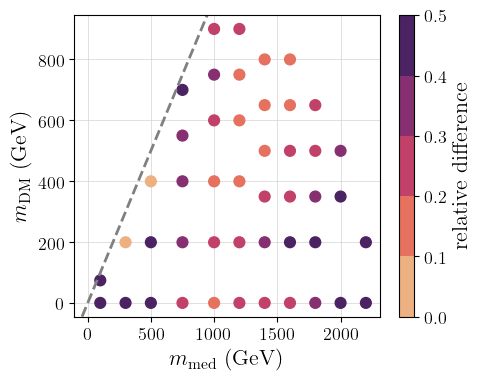

In [13]:
mmed = cutflow['$m_{med}$']
mDM = cutflow['$m_{DM}$']

relDiff = np.abs(cmsCutflow['HCALmitigation($\\phi^{miss}$)'] - cutflow['HCALmitigation($\\phi^{miss}$)'])/np.array(cmsCutflow['HCALmitigation($\\phi^{miss}$)'])

plt.scatter(x=mmed, y=mDM, c=relDiff, cmap=plt.get_cmap('flare', 5), vmin=0., vmax=0.5, s=60)
cbar = plt.colorbar(label=r'relative difference')
cbar.set_ticks([0.,0.1,0.2,0.3,0.4,0.5])
plt.axline((1, 1), slope=1, linestyle='--', color='gray')

plt.xlabel(r'$m_{\rm med}$ (GeV)')
plt.ylabel(r'$m_{\rm DM}$ (GeV)')

plt.tight_layout()


plt.show()

In [39]:
cutflow[(cutflow['$m_{med}$']==1000)&(cutflow['$m_{DM}$']==900)].T

,17
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1000.0
$m_{DM}$,900.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.086368
bin_250.0_280.0_ErrorPlus,0.254059
bin_250.0_280.0_ErrorMinus,0.254059
bin_280.0_310.0,6.02068


In [41]:
cmsCutflow[(cutflow['$m_{med}$']==100)&(cutflow['$m_{DM}$']==1)].T

,0
$m_{med}$,100.0
$m_{DM}$,1.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.047334
$p_{T}^{miss}>250$GeV,0.003092
$p_{T}^{miss}$qualityfilters,0.003092
Electronveto,0.003073


In [18]:
cutflow[(cutflow['$m_{med}$']==1800)&(cutflow['$m_{DM}$']==1)].T

,36
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1800.0
$m_{DM}$,1.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.812074
bin_250.0_280.0_ErrorPlus,0.36424
bin_250.0_280.0_ErrorMinus,0.36424
bin_280.0_310.0,6.470435
